In [16]:
import numpy as np
import matplotlib.pyplot as plt


def compute_1d_power_spectrum(vec_field, num_bins=50):
    """
    Compute the 1D (spherically averaged) power spectrum of a 3D vector field.

    Parameters:
    -----------
    vec_field : ndarray of shape (N, N, N, 3)
        Real-valued vector field defined on a cubic grid.
    num_bins : int
        Number of logarithmic bins in k-space.

    Returns:
    --------
    k_bin_centers : ndarray
        Centers of the logarithmic k bins.
    P_k : ndarray
        Averaged power spectrum values in each bin.
    counts : ndarray
        Number of modes in each bin (can be used for normalization).
    """
    N = vec_field.shape[0]
    assert vec_field.shape == (N, N, N, 3), "Input must be of shape (N, N, N, 3)"

    # Fourier transform (axes 0, 1, 2), keep all vector components
    vec_k = np.fft.fftn(vec_field, axes=(0, 1, 2), norm="ortho")
    vec_k = np.fft.fftshift(vec_k, axes=(0, 1, 2))

    # Power spectrum: sum of squared magnitudes over vector components
    power_density = np.sum(np.abs(vec_k)**2, axis=-1)  # shape: (N, N, N)

    # Compute k-space grid
    kfreq = np.fft.fftfreq(N) * N
    kfreq = np.fft.fftshift(kfreq)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing='ij')
    k_mag = np.sqrt(kx**2 + ky**2 + kz**2).flatten()

    # Flatten power density
    power_flat = power_density.flatten()

    # Avoid k=0 for log binning
    nonzero = k_mag > 0
    k_mag = k_mag[nonzero]
    power_flat = power_flat[nonzero]

    # Logarithmic binning
    kmin = k_mag.min()
    kmax = k_mag.max()
    logbins = np.logspace(np.log10(kmin), np.log10(kmax), num_bins + 1)
    bin_indices = np.digitize(k_mag, logbins)

    # Initialize output
    P_k = np.zeros(num_bins)
    counts = np.zeros(num_bins)
    k_bin_centers = 0.5 * (logbins[:-1] + logbins[1:])

    for i in range(1, num_bins + 1):
        mask = bin_indices == i
        if np.any(mask):
            P_k[i - 1] = power_flat[mask].mean()
            counts[i - 1] = np.sum(mask)

    return k_bin_centers, P_k, counts


In [14]:
import nicegalaxy

galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])

struct = nicegalaxy.map_unstructured_to_structured_3d_batched(galaxy.gas["Coordinates"], galaxy.gas["Velocities"], grid_size=(120, 120, 120))
struct_highres = nicegalaxy.map_unstructured_to_structured_3d_batched(galaxy.gas["Coordinates"], galaxy.gas["Velocities"], grid_size=(300, 300, 300))

Querying KDTree: 100%|██████████| 64/64 [00:04<00:00, 14.58it/s]


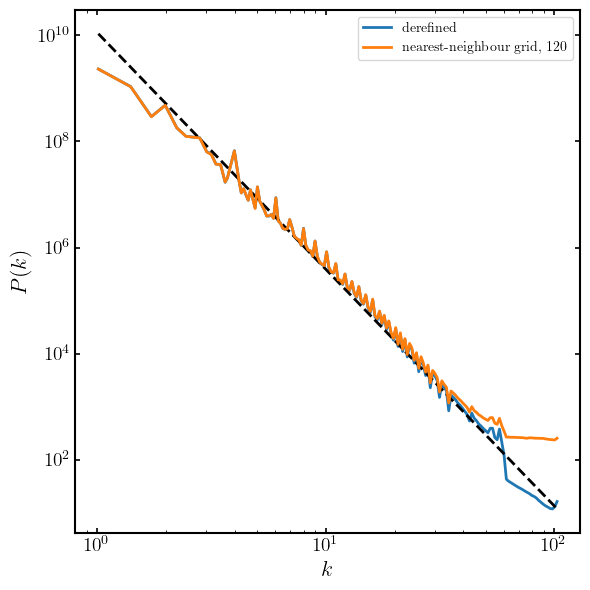

In [21]:
num_bins = 200
vels = np.load("refined_vels.npy")
k, Pk, counts = compute_1d_power_spectrum(vels, num_bins=num_bins)
valid = (Pk > 0) & (counts > 0)
k_valid = k[valid]
Pk_valid = Pk[valid]

# Log-log fit: log10(P) = alpha * log10(k) + C
log_k = np.log10(k_valid)
log_P = np.log10(Pk_valid)
alpha, log_C = np.polyfit(log_k, log_P, deg=1)
C = 10**log_C

# Generate fitted line
Pk_fit = C * k_valid**alpha

# Plot
plt.figure(figsize=(6, 6))
plt.loglog(k_valid, Pk_valid, label="derefined")
plt.loglog(k_valid, Pk_fit, 'k--')

k, Pk, counts = compute_1d_power_spectrum(struct, num_bins=num_bins)
valid = (Pk > 0) & (counts > 0)
k_valid = k[valid]
Pk_valid = Pk[valid]
plt.loglog(k_valid, Pk_valid, label="nearest-neighbour grid, 120")

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
# plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.savefig("derefined_powerspec_comparison.pdf")